Loading model...
Preparing dataset...
Dataset shape: (76265, 82)

MODEL PERFORMANCE

AUC: 0.8340118735183444
Accuracy: 0.9049891824559103
Precision: 0.6188925081433225
Recall: 0.14836022904737117
F1: 0.2393449506613479
Brier Score: 0.0741176594634433

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     68581
           1       0.62      0.15      0.24      7684

    accuracy                           0.90     76265
   macro avg       0.77      0.57      0.59     76265
weighted avg       0.88      0.90      0.88     76265



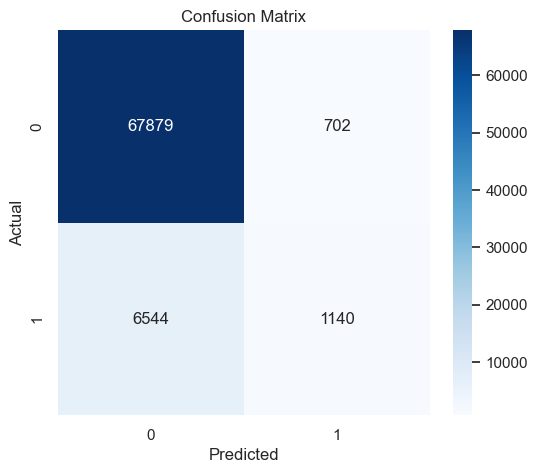

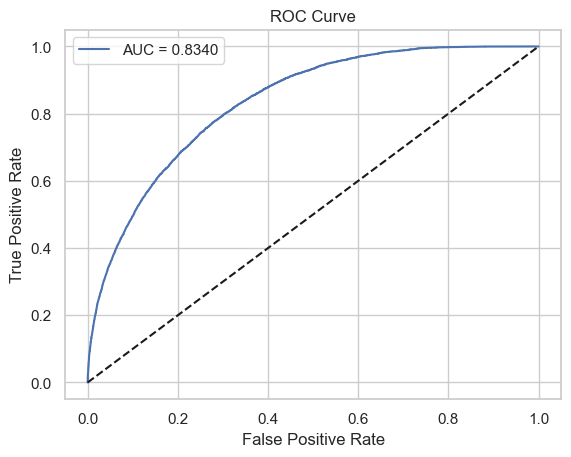

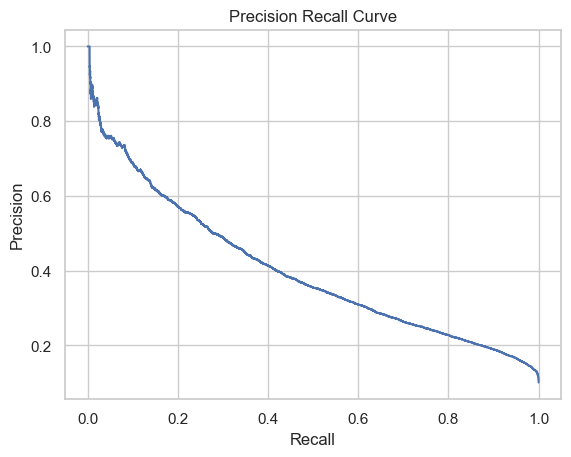

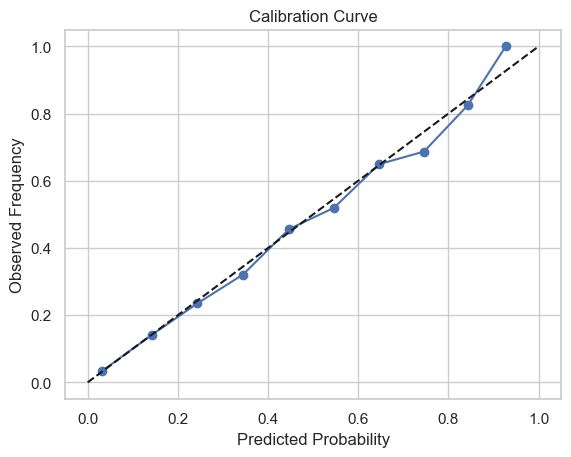


KS Statistic: 0.49665589581122876

Lift Table

        avg_score  conversion_rate  count      lift
decile                                             
9        0.423431         0.409729   7627  4.066626
8        0.208149         0.203121   7626  2.016009
7        0.136608         0.135702   7627  1.346866
6        0.095388         0.097954   7626  0.972214
5        0.066705         0.073171   7626  0.726232
4        0.043594         0.044710   7627  0.443750
3        0.024509         0.027275   7626  0.270710
2        0.011860         0.013111   7627  0.130132
1        0.003680         0.002491   7626  0.024728
0        0.001407         0.000262   7627  0.002603


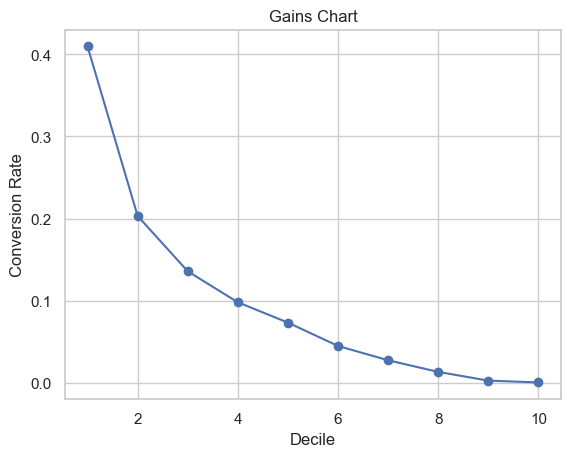

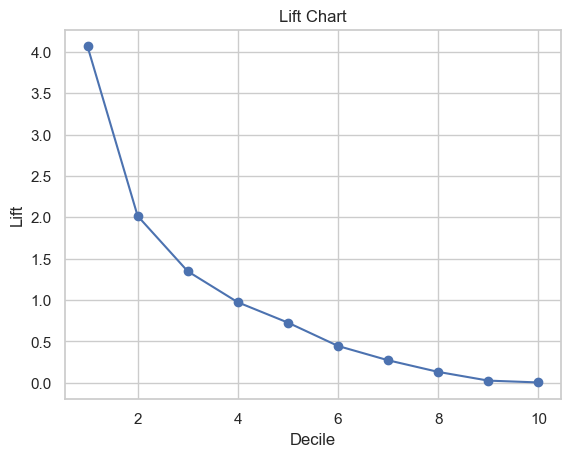

C:\Users\EricVonDohlen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Best Threshold (F1):
threshold    0.207980
precision    0.350819
recall       0.512624
f1           0.416561
Name: 20, dtype: float64


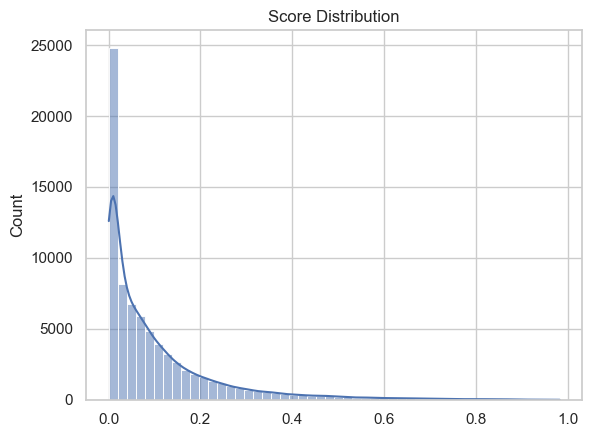


Computing SHAP values...


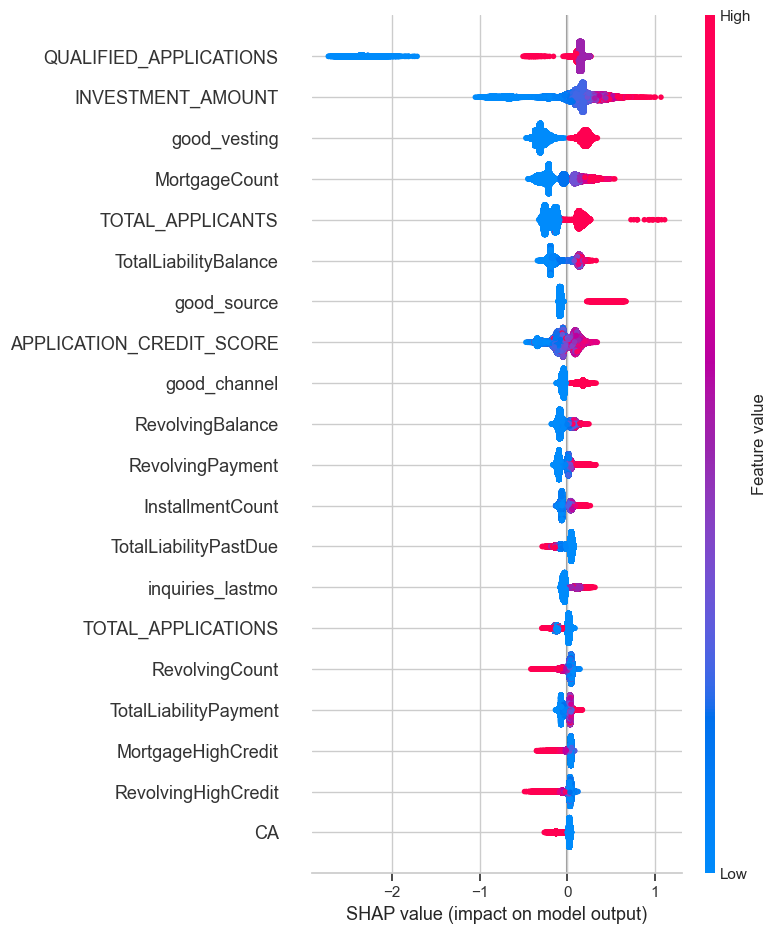


Top Drivers

                     feature  importance
72    QUALIFIED_APPLICATIONS    0.547478
0          INVESTMENT_AMOUNT    0.261579
81              good_vesting    0.254590
26             MortgageCount    0.198636
2           TOTAL_APPLICANTS    0.181934
64     TotalLiabilityBalance    0.154948
80               good_source    0.115092
1   APPLICATION_CREDIT_SCORE    0.112504
79              good_channel    0.076475
55          RevolvingBalance    0.073333
57          RevolvingPayment    0.065893
31          InstallmentCount    0.065551
67     TotalLiabilityPastDue    0.063545
14          inquiries_lastmo    0.055052
71        TOTAL_APPLICATIONS    0.051065
56            RevolvingCount    0.048629
66     TotalLiabilityPayment    0.046720
29        MortgageHighCredit    0.045514
59       RevolvingHighCredit    0.044439
73                        CA    0.043585


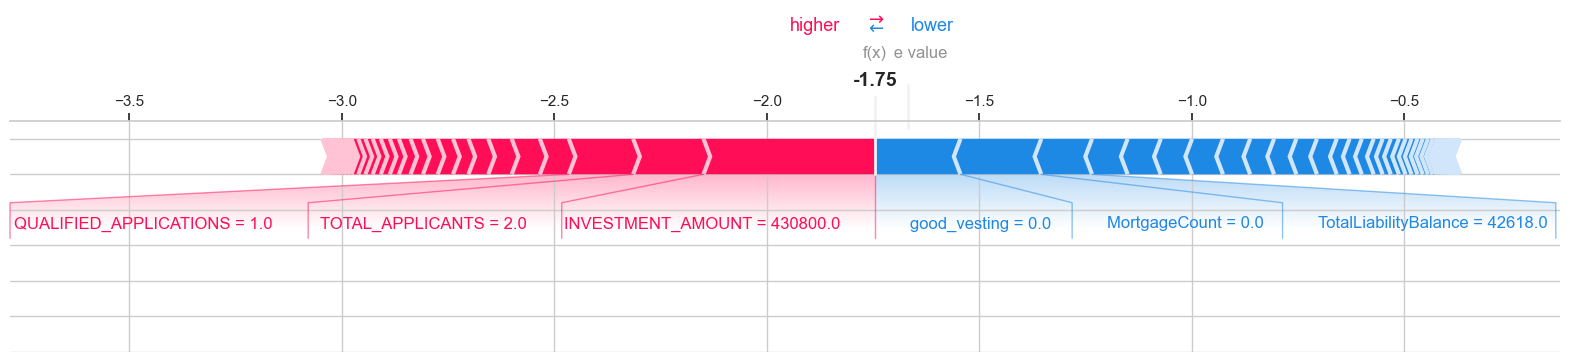


OOF AUC: 0.7817708779234069


In [9]:
# ==========================================================
# PRODUCTION MODEL REPORT
# Compatible with Pipeline V3
# ==========================================================

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    brier_score_loss, f1_score, precision_score,
    recall_score, accuracy_score
)

from sklearn.calibration import calibration_curve

sns.set(style="whitegrid")

# ==========================================================
# CONFIG
# ==========================================================

DATA_PATH = r"C:\Users\EricVonDohlen\OneDrive - Unlock Technologies\Desktop\conversion2\offus_raw_data.csv"

MODEL_DIR = r"C:\Users\EricVonDohlen\model_outputs_v3_offus"

TARGET_COL = "full_target"
ID_COL = "APPLICATION_ID"

# ==========================================================
# LOAD DATA
# ==========================================================

def load_and_clean_data(csv_path, target_col, id_col):

    df = pd.read_csv(csv_path)

    df = df.drop_duplicates()

    ids = df[id_col].copy()

    df = df.loc[:, df.isna().mean() < 0.95]

    nunique = df.nunique()
    df = df.drop(columns=nunique[nunique <= 1].index)

    y = df[target_col]

    if y.dtype == "object":
        y = y.astype("category").cat.codes

    X = df.drop(columns=[target_col, id_col])

    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    high_card = [c for c in cat_cols if X[c].nunique() > 50]

    X = X.drop(columns=high_card)

    cat_cols = [c for c in cat_cols if c not in high_card]

    if len(cat_cols) > 0:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    X = X.replace([np.inf, -np.inf], np.nan)

    return X, y, ids


# ==========================================================
# LOAD MODEL
# ==========================================================

print("Loading model...")

model = joblib.load(f"{MODEL_DIR}/xgb_model.pkl")
beta_cal = joblib.load(f"{MODEL_DIR}/beta_calibrator.pkl")

# ==========================================================
# PREPARE DATA
# ==========================================================

print("Preparing dataset...")

X, y, ids = load_and_clean_data(DATA_PATH, TARGET_COL, ID_COL)

X = X.fillna(X.median())

print("Dataset shape:", X.shape)

# ==========================================================
# PREDICTIONS
# ==========================================================

raw_prob = model.predict_proba(X)[:,1]

y_prob = beta_cal.predict(raw_prob)

y_pred = (y_prob >= 0.5).astype(int)

# ==========================================================
# METRICS
# ==========================================================

print("\nMODEL PERFORMANCE\n")

print("AUC:", roc_auc_score(y, y_prob))
print("Accuracy:", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1:", f1_score(y, y_pred))
print("Brier Score:", brier_score_loss(y, y_prob))

print("\nClassification Report\n")
print(classification_report(y, y_pred))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

fpr, tpr, thresholds = roc_curve(y, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y, y_prob):.4f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==========================================================
# PRECISION RECALL CURVE
# ==========================================================

prec, rec, pr_thresh = precision_recall_curve(y, y_prob)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

# ==========================================================
# CALIBRATION CURVE
# ==========================================================

prob_true, prob_pred = calibration_curve(y, y_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.show()

# ==========================================================
# KS STATISTIC
# ==========================================================

ks = max(tpr - fpr)

print("\nKS Statistic:", ks)

# ==========================================================
# DECILES / LIFT TABLE
# ==========================================================

df_eval = pd.DataFrame({
    "id": ids,
    "target": y,
    "score": y_prob
})

df_eval["decile"] = pd.qcut(df_eval["score"], 10, labels=False, duplicates="drop")

lift_table = df_eval.groupby("decile").agg(
    avg_score=("score","mean"),
    conversion_rate=("target","mean"),
    count=("target","count")
).sort_index(ascending=False)

baseline = df_eval["target"].mean()

lift_table["lift"] = lift_table["conversion_rate"] / baseline

print("\nLift Table\n")
print(lift_table)

lift_table.to_csv(f"{MODEL_DIR}/lift_table.csv")

# ==========================================================
# GAINS CHART
# ==========================================================

plt.figure()

plt.plot(range(1,len(lift_table)+1), lift_table["conversion_rate"], marker="o")

plt.xlabel("Decile")
plt.ylabel("Conversion Rate")

plt.title("Gains Chart")

plt.show()

# ==========================================================
# LIFT CHART
# ==========================================================

plt.figure()

plt.plot(range(1,len(lift_table)+1), lift_table["lift"], marker="o")

plt.xlabel("Decile")
plt.ylabel("Lift")

plt.title("Lift Chart")

plt.show()

# ==========================================================
# THRESHOLD OPTIMIZATION
# ==========================================================

thresholds = np.linspace(0.01,0.99,100)

metrics = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    metrics.append([
        t,
        precision_score(y,pred),
        recall_score(y,pred),
        f1_score(y,pred)
    ])

metrics = pd.DataFrame(metrics, columns=["threshold","precision","recall","f1"])

best = metrics.iloc[metrics["f1"].idxmax()]

print("\nBest Threshold (F1):")
print(best)

# ==========================================================
# SCORE DISTRIBUTION
# ==========================================================

plt.figure()

sns.histplot(y_prob, bins=50, kde=True)

plt.title("Score Distribution")

plt.show()

# ==========================================================
# SHAP EXPLANATIONS
# ==========================================================

print("\nComputing SHAP values...")

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

# ==========================================================
# SHAP FEATURE IMPORTANCE
# ==========================================================

importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

print("\nTop Drivers\n")

print(importance_df.head(20))

importance_df.to_csv(f"{MODEL_DIR}/feature_importance.csv")

# ==========================================================
# INDIVIDUAL PREDICTION EXPLANATION
# ==========================================================

row = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[row],
    X.iloc[row],
    matplotlib=True
)

# ==========================================================
# OOF PERFORMANCE
# ==========================================================

try:

    oof = pd.read_csv(f"{MODEL_DIR}/oof_scores.csv")

    print("\nOOF AUC:", roc_auc_score(oof["target"], oof["pred_score"]))

except:
    print("No OOF scores found.")